In [70]:
import os
import numpy
import matplotlib.pyplot as plt
import pandas as pd
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.family']


['Malgun Gothic']

In [71]:
reviews = [
"이 제품 정말 좋아요. 다음에도 구매의향 있습니다.",
"배송이 너무 늦어서 실망했습니다.",
"가격 대비 품질이 훌륭합니다.",
"설명과 똑같은 제품이 와서 만족합니다.",
"제품이 고장나서 AS를 받았습니다.",
"AS 처리 과정이 너무 번거로웠습니다.",
"추천하고 싶은 제품입니다.",
"포장이 꼼꼼해서 기분이 좋았습니다.",
"생각보다 품질이 별로라 아쉬웠습니다.",
"사용해보니 기능이 정말 편리합니다.",
"가격이 조금 비싸지만 성능은 만족스럽습니다.",
"설치 방법이 어려워서 처음엔 힘들었습니다."
]

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
word_vec = TfidfVectorizer()
m_word = word_vec.fit_transform(reviews)
print(m_word)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 53 stored elements and shape (12, 49)>
  Coords	Values
  (0, 35)	0.41748077270537354
  (0, 34)	0.35853733711654234
  (0, 39)	0.41748077270537354
  (0, 12)	0.41748077270537354
  (0, 6)	0.41748077270537354
  (0, 33)	0.41748077270537354
  (1, 19)	0.5172566287016166
  (1, 10)	0.4442260012569211
  (1, 11)	0.5172566287016166
  (1, 28)	0.5172566287016166
  (2, 2)	0.5172566287016166
  (2, 13)	0.5172566287016166
  (2, 46)	0.4442260012569211
  (2, 47)	0.5172566287016166
  (3, 25)	0.4594336046639039
  (3, 14)	0.4594336046639039
  (3, 36)	0.3945669165327051
  (3, 32)	0.4594336046639039
  (3, 16)	0.4594336046639039
  (4, 36)	0.4442260012569211
  (4, 4)	0.5172566287016166
  (4, 1)	0.5172566287016166
  (4, 17)	0.5172566287016166
  (5, 10)	0.3945669165327051
  (5, 0)	0.4594336046639039
  :	:
  (6, 43)	0.5773502691896257
  (6, 29)	0.5773502691896257
  (6, 37)	0.5773502691896257
  (7, 45)	0.5
  (7, 9)	0.5
  (7, 8)	0.5
  (7, 40)	0.5
  (8, 46)	

In [73]:
for q in ["품질이", "배송이"]:
    s = cosine_similarity(word_vec.transform([q]), m_word)[0]
    print(f'search {q} highest similarity {s.max():.2f} ("{reviews[s.argmax()][:20]}...")')
#형태소 분석을 안해서 '배송'자체로는 나오지 않는다.

search 품질이 highest similarity 0.44 ("가격 대비 품질이 훌륭합니다....")
search 배송이 highest similarity 0.52 ("배송이 너무 늦어서 실망했습니다....")


In [74]:
#형태소 분석기 설치
!pip install kiwipiepy 
#설치명령어는 대소문자를 구분하지 않거나 기본적으로 소문자를 사용해서 대문자K를 안써도 된것이다. 
#파이썬에서는 대소문자를 엄격하게 구분한다. 

In [75]:
#한국어 형태소 분석기 "품질이" 품질(명사)+ 이(조사)로 쪼개 형태소(명사, 동사, 형용사)만 추출
from kiwipiepy import Kiwi
kiwi = Kiwi()
# 3. 토큰화 실행
print([(t.form, t.tag) for t in kiwi.tokenize('가격 대비 품질이 훌륭합니다.')])

[('가격', 'NNG'), ('대비', 'NNG'), ('품질', 'NNG'), ('이', 'JKS'), ('훌륭하', 'VA'), ('ᆸ니다', 'EF'), ('.', 'SF')]


In [76]:
#의미 있는 형태소 추출
def tokenize_korean(text):
    return [t.form for t in kiwi.tokenize(text) if t.tag[:2] in ['NN', 'VV', 'VA', 'SL']]
print('형태소', tokenize_korean('가격 대비 품질이 훌륭합니다.'))

형태소 ['가격', '대비', '품질', '훌륭하']


In [90]:
kiwi_vec = TfidfVectorizer(tokenizer=tokenize_korean, token_pattern =None)
m_kiwi = kiwi_vec.fit_transform(reviews)

print('형태소 특징 수:', m_kiwi.shape[1])

형태소 특징 수: 38


In [78]:
for q in ['품질', '배송', 'AS']:
    s = cosine_similarity(kiwi_vec.transform([q]), m_kiwi)[0]
    print(f' search{q} -> ({s.max():.2f}) {reviews[s.argmax()]}')


 search품질 -> (0.52) 생각보다 품질이 별로라 아쉬웠습니다.
 search배송 -> (0.58) 배송이 너무 늦어서 실망했습니다.
 searchAS -> (0.52) AS 처리 과정이 너무 번거로웠습니다.


use New Data: News data 

In [79]:
# news = pd.read_csv('../week3/Data_processing/news_sample.csv', encoding='utf-8-sig').dropna(subset=['title','text'])
# news = news.reset_index(drop=True)
# print('news number:', len(news), '/part', news['category'].nunique())
# print(news['category'].value_counts().to_dict())

news number: 2100 /part 7
{'라이프': 300, '부동산': 300, '산업': 300, '스포츠': 300, '연예': 300, '오피니언': 300, '증권': 300}


In [80]:
# news_vec = TfidfVectorizer(tokenizer=tokenize_korean, token_pattern = None, 
#                           max_features = 10000)
# news_matrix = news_vec.fit_transform(news['text'])
# print('news tf-idf array', news_matrix.shape)

news tf-idf array (2100, 10000)


In [81]:
# def search_news(query, n=5):
#     scores = cosine_similarity(news_vec.transform([query]), news_matrix)[0]
#     order = scores.argsort()[::-1][:n]
#     return pd.DataFrame({
#         'similarity': scores[order].round(2),
#         'part':news['category'].values[order],
#         'title': news['title'].values[order]        
#     })

In [82]:
# print(search_news('과학').to_string(index=False))

 similarity part                             title
       0.33  부동산 부산 ‘세계 최초 해상도시’ 해양과학기술협회와 손잡고 만든다
       0.19  라이프 기고] 반세기 일자리 책임질 `과학기술 창업본부` 닻 올랐다
       0.17 오피니언                 [매경춘추] 직업윤리와 대학교육
       0.17 오피니언              [기고] ESG, 이제는 과학기술이다
       0.15 오피니언          [기고] 바이오에서는 파운드리 산업 앞서가자


In [93]:
!pip install wordcloud

In [94]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

In [95]:
# #wordcloud need font
# font_path = fm.findfont(plt.rcParams['font.family'][0])
# #extract words and excute word cloud using exist frequency
# def category_wordcloud(cate, ax):
#     words = []
#     for doc in news.loc[news['category']==cate, 'text']:
#         words += [w for w in tokenize_korean(doc) if len(w) >1] #except one letter word
#         freq = Counter(words)
#         wc = WordCloud(font_path=font_path, background_color='white', width=500, height=350)
#         wc.generate_from_frequencies(freq)
#         ax.imshow(wc); ax.axis('off'); ax.set_title(cate)

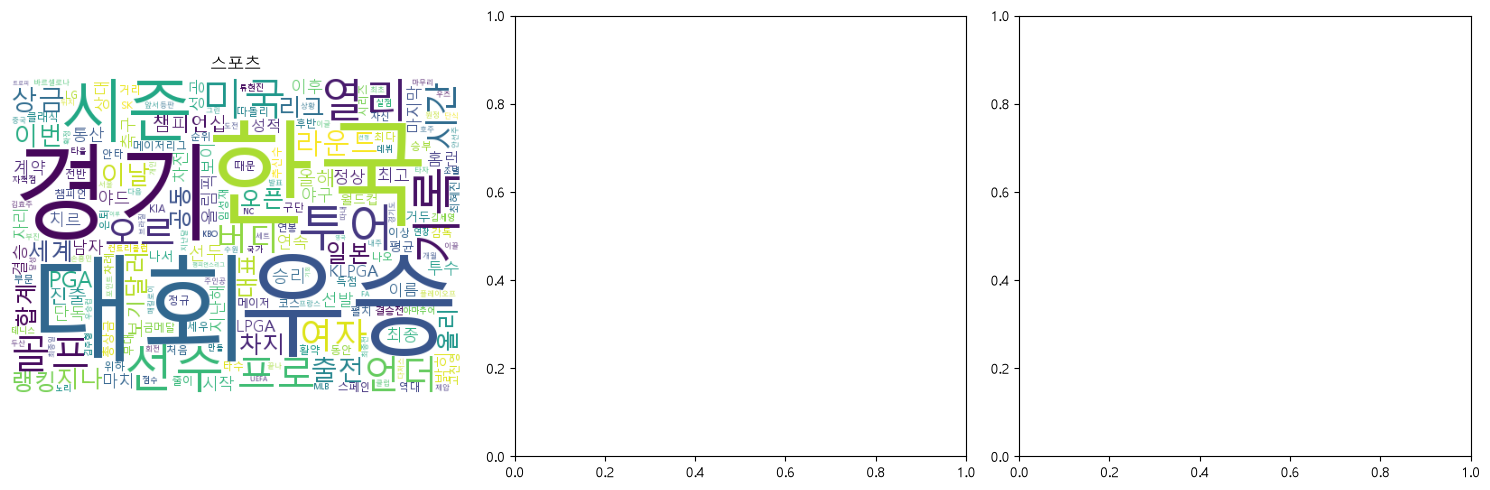

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for cate, ax in zip(['스포츠','연애'], axes):
    category_wordcloud(cate, ax)
plt.tight_layout()
plt.show()

In [100]:
# 1. Matplotlib에서 사용하는 폰트 경로 가져오기 (한글 깨짐 방지)
font_path = fm.findfont(plt.rcParams['font.family'][0])
#전체 reviews 데이터에서 형태소 추출(1글자 제외)
words=[]
for doc in reviews:
    words += [w for w in tokenize_korean(doc) if len(w)>1]
freq = Counter(words)
#워드클라우드 객체 생성 및 빈도수 기반 워드클라우드 생성
wc = WordCloud(
    font_path=font_path,
    background_color='white', 
    width=600,
    height=400)
wc.generate_from_frequencies(freq)
ax.imshow(wc)
ax.axis('off') #축 눈금 제거
ax.set_title('Review Word Cloud', fontsize=15)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

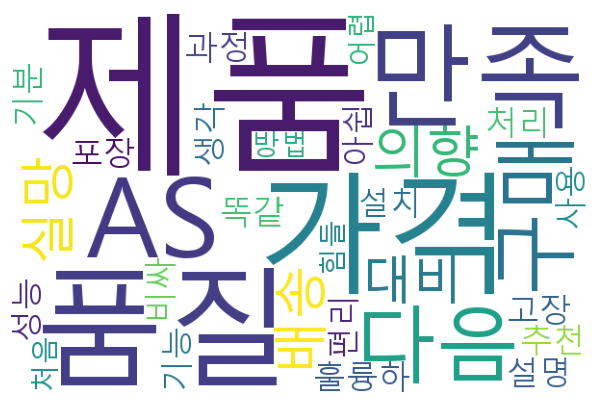

In [101]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
#폰트 처리때문에 다른 방식으로 
# 1. 단어 모으기 (1글자 제외)
words = [w for doc in reviews for w in tokenize_korean(doc) if len(w) > 1]
freq = Counter(words)

# 2. 윈도우 기본 한글 폰트(Malgun Gothic) 직접 지정
font_path = 'C:/Windows/Fonts/malgun.ttf'

# 3. 워드클라우드 생성 및 바로 출력
wc = WordCloud(font_path=font_path, background_color='white', width=600, height=400).generate_from_frequencies(freq)

plt.figure(figsize=(8, 5))
plt.imshow(wc)
plt.axis('off')
plt.show()